## Importando as Bibliotecas que serão utilizadas:

In [13]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import missingno as miss
import folium 
import geopandas as geop
import os

## Carregando os Dados

In [14]:
os.chdir(r'D:\Lucas\OneDrive\IESB\Projetos\Projeto.Integrador-Analise.Acidentes.Transito.BR')

print(os.getcwd())

D:\Lucas\OneDrive\IESB\Projetos\Projeto.Integrador-Analise.Acidentes.Transito.BR


In [15]:
# Carregando a primeira base: Dados/acidentes2025_todas_causas_tipos.csv e visualizando as primeiras 10 linhas
acidentes_2025 = pd.read_csv('Dados\\acidentes2025_todas_causas_tipos.csv', sep= ';', encoding= 'latin-1')

acidentes_2025.head()

,id,pesid,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_principal,...,sexo,ilesos,feridos_leves,feridos_graves,mortos,latitude,longitude,regional,delegacia,uop
0,652468,1467636.0,2025-01-01,quarta-feira,00:30:00,PE,101.0,"89,5",JABOATAO DOS GUARARAPES,Sim,...,Não Informado,0.0,0.0,0.0,0.0,"-8,20760697","-34,98372005",SPRF-PE,DEL01-PE,UOP01-DEL01-PE
1,652468,1467635.0,2025-01-01,quarta-feira,00:30:00,PE,101.0,"89,5",JABOATAO DOS GUARARAPES,Sim,...,Feminino,0.0,1.0,0.0,0.0,"-8,20760697","-34,98372005",SPRF-PE,DEL01-PE,UOP01-DEL01-PE
2,652468,1467634.0,2025-01-01,quarta-feira,00:30:00,PE,101.0,"89,5",JABOATAO DOS GUARARAPES,Sim,...,Masculino,0.0,1.0,0.0,0.0,"-8,20760697","-34,98372005",SPRF-PE,DEL01-PE,UOP01-DEL01-PE
3,652468,1467637.0,2025-01-01,quarta-feira,00:30:00,PE,101.0,"89,5",JABOATAO DOS GUARARAPES,Sim,...,Não Informado,0.0,0.0,0.0,0.0,"-8,20760697","-34,98372005",SPRF-PE,DEL01-PE,UOP01-DEL01-PE
4,652469,1467628.0,2025-01-01,quarta-feira,00:50:00,SC,101.0,120,ITAJAI,Sim,...,Feminino,0.0,1.0,0.0,0.0,"-26,912758","-48,711998",SPRF-SC,DEL04-SC,UOP04-DEL04-SC


In [16]:
# Carregando a segunda base: Dados/datatran2017-2024.CSV e visualizando as primeiras 10 linhas
acidentes_2017a2024 = pd.read_csv('Dados\datatran2017-2024.CSV', encoding= 'latin-1', sep= ';')

acidentes_2017a2024.head()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\lucas\AppData\Local\Temp\ipykernel_16004\2076468110.py:2: SyntaxWarning: invalid escape sequence '\d'
  acidentes_2017a2024 = pd.read_csv('Dados\datatran2017-2024.CSV', encoding= 'latin-1', sep= ';')


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,17,01/01/2017,domingo,01:45:00,RS,116,"34,9",VACARIA,Defeito Mecânico no Veículo,Colisão traseira,...,0,2,0,4,2,"-28,5071196","-50,941176",SPRF-RS,DEL05-RS,UOP03-DEL05-RS
1,20,01/01/2017,domingo,01:00:00,PR,376,636,TIJUCAS DO SUL,Velocidade Incompatível,Saída de leito carroçável,...,0,1,0,0,2,"-25,754","-49,1266",SPRF-PR,DEL01-PR,DEL7/1-UOP08/PR
2,69,01/01/2017,domingo,04:40:00,BA,101,65,ENTRE RIOS,Condutor Dormindo,Colisão frontal,...,1,2,0,2,2,"-11,9618","-38,0953",SPRF-BA,DEL01-BA,UOP04-DEL01-BA
3,106,01/01/2017,domingo,06:30:00,PA,316,"72,5",CASTANHAL,Falta de Atenção à Condução,Colisão lateral,...,0,3,0,0,3,"-1,2899799","-47,83483207",SPRF-PA,DEL01-PA,DEL19/1-UOP02/PA
4,109,01/01/2017,domingo,09:00:00,GO,20,"220,5",POSSE,Defeito na Via,Colisão com objeto estático,...,1,0,1,3,2,"-14,14220931","-46,32258922",SPRF-DF,DEL02-DF,UOP03-DEL02-DF


# Análise de Acidentes em Rodovias Federais Brasileiras (2017–2025)
## **1 — Análise Exploratória de Dados, Limpeza e Tratamento**

**Fonte dos dados:**
- [PRF Dados Abertos](https://www.gov.br/prf/pt-br/acesso-a-informacao/dados-abertos) — Acidentes 2025
- [Kaggle](https://www.kaggle.com/) — Acidentes 2017–2024

**Objetivo:** Unir, limpar e tratar os dois conjuntos de dados para posterior
uso em dashboards no Power BI e modelo de Machine Learning.

**Dataset final:** 609.532 registros | 27 colunas | Período: 2017–2025

In [17]:
## Carregando informações do conjunto de dados acidentes_2025:
acidentes_2025.info()

<class 'pandas.DataFrame'>
RangeIndex: 584010 entries, 0 to 584009
Data columns (total 37 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      584010 non-null  int64  
 1   pesid                   527209 non-null  float64
 2   data_inversa            584010 non-null  str    
 3   dia_semana              584010 non-null  str    
 4   horario                 584010 non-null  str    
 5   uf                      584010 non-null  str    
 6   br                      582566 non-null  float64
 7   km                      582566 non-null  str    
 8   municipio               584010 non-null  str    
 9   causa_principal         584010 non-null  str    
 10  causa_acidente          584010 non-null  str    
 11  ordem_tipo_acidente     584010 non-null  int64  
 12  tipo_acidente           584010 non-null  str    
 13  classificacao_acidente  584003 non-null  str    
 14  fase_dia                584010 

In [18]:
## Carregando informações do conjunto de dados acidentes_2017a2024:
acidentes_2017a2024.info()

<class 'pandas.DataFrame'>
RangeIndex: 547347 entries, 0 to 547346
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   id                      547347 non-null  int64
 1   data_inversa            547347 non-null  str  
 2   dia_semana              547347 non-null  str  
 3   horario                 547347 non-null  str  
 4   uf                      547347 non-null  str  
 5   br                      547347 non-null  int64
 6   km                      547347 non-null  str  
 7   municipio               547347 non-null  str  
 8   causa_acidente          547347 non-null  str  
 9   tipo_acidente           547306 non-null  str  
 10  classificacao_acidente  547338 non-null  str  
 11  fase_dia                547347 non-null  str  
 12  sentido_via             547347 non-null  str  
 13  condicao_metereologica  547347 non-null  str  
 14  tipo_pista              547347 non-null  str  
 15  tracado_via

## **Observações Importantes**

> Após primeira análise dos atributos e registros dos dois datasets: [acidentes_2025](../Dados/acidentes2025_todas_causas_tipos.csv) e [acidentes_2017a2024](../Dados/datatran2017-2024.CSV), foram identificados os seguintes problemas que precisam ser tratados:

---

### ***Mapeamento das Colunas***

**Colunas em comum** (base do merge):

`id`, `data_inversa`, `dia_semana`, `horario`, `uf`, `br`, `km`, `municipio`, `causa_acidente`, `tipo_acidente`, `classificacao_acidente`, `fase_dia`, `sentido_via`, `condicao_metereologica`, `tipo_pista`, `tracado_via`, `uso_solo`, `mortos`, `feridos_leves`, `feridos_graves`, `ilesos`, `latitude`, `longitude`, `regional`, `delegacia`, `uop`

**Só no 2025** — colunas exclusivas (serão descartadas):

`pesid`, `causa_principal`, `ordem_tipo_acidente`, `id_veiculo`, `tipo_veiculo`, `marca`, `ano_fabricacao_veiculo`, `tipo_envolvido`, `estado_fisico`, `idade`, `sexo`

**Só no 2017-2024** — colunas exclusivas (serão descartadas):

`pessoas`, `ignorados`, `feridos`, `veiculos`

---

### ***Inconsistências de Tipos de Dados***

**Colunas com mesmo nome mas tipos diferentes entre os datasets:**

| Coluna | 2025 | 2017-2024 |
|---|---|---|
| `br` | float64 | int64 |
| `mortos` | float64 | int64 |
| `feridos_leves` | float64 | int64 |
| `feridos_graves` | float64 | int64 |
| `ilesos` | float64 | int64 |

> No dataset 2025 essas colunas vieram como **float64** por causa dos valores ausentes (NaN) —
> o pandas converte `int` para `float` automaticamente quando há NaN na coluna.

**Colunas que precisam de conversão de tipo em ambos os datasets:**

| Coluna | Tipo Atual | Tipo Esperado | Motivo |
|---|---|---|---|
| `data_inversa` | str | datetime | Necessário para análises temporais |
| `latitude` | str | float64 | Necessário para análises geoespaciais |
| `longitude` | str | float64 | Necessário para análises geoespaciais |
| `km` | str | float64 | Necessário para análises por trecho de rodovia |

---

**Inconsistência na coluna 'data_inversa' no dataset 2017-2024**

O conjunto de dados do dataset [datatran2017-2024.CSV](../Dados/datatran2017-2024.CSV) do Kaggle usa formato de data americano (MM/DD/YYYY) com ano às vezes abreviado, o que é incomum para um dataset brasileiro. Provavelmente ocorreu durante o processo de exportação no Kaggle.

---

### ***Medidas a Serem Tomadas nas Próximas Etapas:***

1. **Selecionar apenas as colunas comuns** nos dois datasets antes de qualquer tratamento
2. **Converter `data_inversa`** para datetime com `pd.to_datetime()`
3. **Converter `latitude` e `longitude`** para float64 após padronizar separadores decimais (padrão brasileiro: vírgula → ponto)
4. **Converter `km`** para float64 após padronizar separadores decimais
5. **Converter `br`, `mortos`, `feridos_leves`, `feridos_graves` e `ilesos`** para `Int64` após tratar os NaN — uso de nullable integer por conta dos valores ausentes no dataset 2025
6. **Identificar e tratar valores ausentes** — estratégia mista: remoção de linhas para volumes abaixo de 1,5%, e `fillna(0)` nas colunas de vítimas do dataset 2025 (NaN estrutural confirmado por investigação)
7. **Padronizar categorias** — verificar e corrigir inconsistências em `causa_acidente`, `sentido_via` e `condicao_metereologica`; manter categorias exclusivas sem equivalente entre os datasets
8. **Tratar duplicatas** — dataset 2025 possui granularidade por pessoa (múltiplas linhas por acidente); estratégia: agregar para 1 linha por acidente com `groupby().agg()`, somando colunas de vítimas e preservando demais atributos com `first`
9. **Adicionar coluna `fonte`** para identificar a origem de cada registro após o merge (`'2017-2024'` ou `'2025'`)
10. **Realizar o merge** com `pd.concat()` após todos os tratamentos individuais

## **Etapa 1: Selecionando apenas as colunas comuns:**
Excluindo todas as colunas exclusivas dos dois datasets.

In [19]:
# Definindo as colunas comuns que serão mantidas nos dois datasets
colunas_comuns = [
    'id',
    'data_inversa',
    'dia_semana',
    'horario',
    'uf',
    'br',
    'km',
    'municipio',
    'causa_acidente',
    'tipo_acidente',
    'classificacao_acidente',
    'fase_dia',
    'sentido_via',
    'condicao_metereologica',
    'tipo_pista',
    'tracado_via',
    'uso_solo',
    'mortos',
    'feridos_leves',
    'feridos_graves',
    'ilesos',
    'latitude',
    'longitude',
    'regional',
    'delegacia',
    'uop'
]

# Selecionando apenas as colunas comuns em cada dataset
acidentes_2025 = acidentes_2025[colunas_comuns].copy()
acidentes_2017a2024 = acidentes_2017a2024[colunas_comuns].copy()

# Confirmando
print("2025:", acidentes_2025.shape)
print("2017-2024:", acidentes_2017a2024.shape)
print("\nColunas 2025:", acidentes_2025.columns.tolist())
print("Colunas 2017-2024:", acidentes_2017a2024.columns.tolist())

2025: (584010, 26)
2017-2024: (547347, 26)

Colunas 2025: ['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop']
Colunas 2017-2024: ['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop']


In [20]:
# Verificando 1:
acidentes_2025.head(2)

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,uso_solo,mortos,feridos_leves,feridos_graves,ilesos,latitude,longitude,regional,delegacia,uop
0,652468,2025-01-01,quarta-feira,00:30:00,PE,101.0,"89,5",JABOATAO DOS GUARARAPES,Reação tardia ou ineficiente do condutor,Colisão traseira,...,Não,0.0,0.0,0.0,0.0,"-8,20760697","-34,98372005",SPRF-PE,DEL01-PE,UOP01-DEL01-PE
1,652468,2025-01-01,quarta-feira,00:30:00,PE,101.0,"89,5",JABOATAO DOS GUARARAPES,Reação tardia ou ineficiente do condutor,Colisão traseira,...,Não,0.0,1.0,0.0,0.0,"-8,20760697","-34,98372005",SPRF-PE,DEL01-PE,UOP01-DEL01-PE


In [21]:
# Verificando 2:
acidentes_2017a2024.head(2)

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,uso_solo,mortos,feridos_leves,feridos_graves,ilesos,latitude,longitude,regional,delegacia,uop
0,17,01/01/2017,domingo,01:45:00,RS,116,"34,9",VACARIA,Defeito Mecânico no Veículo,Colisão traseira,...,Não,0,4,0,2,"-28,5071196","-50,941176",SPRF-RS,DEL05-RS,UOP03-DEL05-RS
1,20,01/01/2017,domingo,01:00:00,PR,376,636,TIJUCAS DO SUL,Velocidade Incompatível,Saída de leito carroçável,...,Não,1,0,0,1,"-25,754","-49,1266",SPRF-PR,DEL01-PR,DEL7/1-UOP08/PR


## **Etapa 2: Convertendo Coluna data_inversa para Datetime em ambos datasets:**
convertedo as o tipo das colunas 'data_inversa' das duas tabelas de acidentes de string para datetime

In [22]:
# Convertendo tipo de dado da coluna data_inversa (string -- para datetime) -- acidentes_2025:
acidentes_2025['data_inversa'] = pd.to_datetime(acidentes_2025['data_inversa'], format= "%Y-%m-%d")

print(acidentes_2025['data_inversa'].dtype)
print(acidentes_2025['data_inversa'].head(2500))


datetime64[us]
0      2025-01-01
1      2025-01-01
2      2025-01-01
3      2025-01-01
4      2025-01-01
          ...    
2495   2025-01-02
2496   2025-01-02
2497   2025-01-02
2498   2025-01-02
2499   2025-01-02
Name: data_inversa, Length: 2500, dtype: datetime64[us]


In [23]:
# Convertendo tipo de dado da coluna data_inversa (string -- para datetime) -- acidentes_2017a2024:
acidentes_2017a2024['data_inversa'] = pd.to_datetime(
    acidentes_2017a2024['data_inversa'],
    format='mixed',
    dayfirst=False  # o primeiro número é o mês (padrão americano)
)

print(acidentes_2017a2024['data_inversa'].dtype)
print(acidentes_2017a2024['data_inversa'].head(82))

datetime64[us]
0    2017-01-01
1    2017-01-01
2    2017-01-01
3    2017-01-01
4    2017-01-01
        ...    
77   2017-01-02
78   2017-01-02
79   2017-01-03
80   2017-01-03
81   2017-01-03
Name: data_inversa, Length: 82, dtype: datetime64[us]


## **Etapa 3: Conversão das colunas longitude e latitude para float**
> 1º Tratando o padrão brasileiro (Vírgula por Ponto)

É muito comum em datasets brasileiros que os decimais venham com vírgula (ex: "10,50"). O Python não entende a vírgula como separador decimal por padrão, então precisamos trocá-la antes de converter.

> 2º Transformando para float

utilizando a função `.astype(float)`

In [24]:
print(acidentes_2017a2024['latitude'].dtype)
print(acidentes_2017a2024['longitude'].dtype)

print(acidentes_2025['latitude'].dtype)
print(acidentes_2025['longitude'].dtype)

str
str
str
str


In [25]:
# Convertendo o tipo da coluna 'latitude' e 'longitude' do Dataset acidentes_2017a2024
"""
1. Remove o ponto de milhar (se houver)
2. Troca a vírgula pelo ponto
3. Converte para float
"""
acidentes_2017a2024['latitude'] = acidentes_2017a2024['latitude'].str.replace('.', '').str.replace(',', '.').astype(float)
acidentes_2017a2024['longitude'] = acidentes_2017a2024['longitude'].str.replace('.', '').str.replace(',', '.').astype(float)

print(acidentes_2017a2024['latitude'].dtype)
print(acidentes_2017a2024['longitude'].dtype)

print(acidentes_2017a2024['latitude'].head(2))

float64
float64
0   -28.50712
1   -25.75400
Name: latitude, dtype: float64


In [26]:
# Convertendo o tipo da coluna 'latitude' e 'longitude' do Dataset acidentes_2025

acidentes_2025['latitude'] = acidentes_2025['latitude'].str.replace('.', '').str.replace(',', '.').astype(float)
acidentes_2025['longitude'] = acidentes_2025['longitude'].str.replace('.', '').str.replace(',', '.').astype(float)

print(acidentes_2025['latitude'].dtype)
print(acidentes_2025['longitude'].dtype)

print(acidentes_2025['latitude'].head(2))

float64
float64
0   -8.207607
1   -8.207607
Name: latitude, dtype: float64


## **Etapa 4: Conversão da coluna km para float e padronizando separadores decimais:**

In [27]:
print(acidentes_2025['km'].dtype)
print(acidentes_2017a2024['km'].dtype)

print(acidentes_2017a2024['km'].head(15))

str
str
0      34,9
1       636
2        65
3      72,5
4     220,5
5        30
6     249,5
7     483,1
8       469
9       375
10     23,7
11    338,9
12     11,8
13    672,8
14    290,5
Name: km, dtype: str


In [28]:
# Convertendo o tipo da coluna 'km' dos Datasets 

acidentes_2025['km'] = acidentes_2025['km'].str.replace('.', '').str.replace(',', '.').astype(float)
acidentes_2017a2024['km'] = acidentes_2017a2024['km'].str.replace('.', '').str.replace(',', '.').astype(float)

print(f"O tipo da coluna 'km' do Dataframe -- acidentes_2025 é: {acidentes_2025['km'].dtype}")
print(f"O tipo da coluna 'km' do Dataframe -- acidentes_2017a2024 é: {acidentes_2017a2024['km'].dtype}")

print(acidentes_2025['km'].head(2))

O tipo da coluna 'km' do Dataframe -- acidentes_2025 é: float64
O tipo da coluna 'km' do Dataframe -- acidentes_2017a2024 é: float64
0    89.5
1    89.5
Name: km, dtype: float64


## **Etapa 5: Conversão das colunas: `br`, `mortos`, `feridos_leves`, `feridos_graves` e `ilesos` para int64 para depois tratar os NaN**
> Realizando a conversão a força com a função `pd.to_numeric(data, errors='coerce')` para transformar os valores em númericos e os valores inconsistentes em NaN

In [29]:
# Convertendo os valores da tabela acidentes_2017a2024
acidentes_2017a2024['br'] = pd.to_numeric(acidentes_2017a2024['br'], errors='coerce')
acidentes_2017a2024['mortos'] = pd.to_numeric(acidentes_2017a2024['mortos'], errors='coerce')
acidentes_2017a2024['feridos_leves'] = pd.to_numeric(acidentes_2017a2024['feridos_leves'], errors='coerce')
acidentes_2017a2024['feridos_graves'] = pd.to_numeric(acidentes_2017a2024['feridos_graves'], errors='coerce')
acidentes_2017a2024['ilesos'] = pd.to_numeric(acidentes_2017a2024['ilesos'], errors='coerce')


print(acidentes_2017a2024['br'].dtype)
print(acidentes_2017a2024['mortos'].dtype)
print(acidentes_2017a2024['feridos_leves'].dtype)
print(acidentes_2017a2024['ilesos'].dtype)

int64
int64
int64
int64


In [30]:
acidentes_2017a2024.head(2)

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,uso_solo,mortos,feridos_leves,feridos_graves,ilesos,latitude,longitude,regional,delegacia,uop
0,17,2017-01-01,domingo,01:45:00,RS,116,34.9,VACARIA,Defeito Mecânico no Veículo,Colisão traseira,...,Não,0,4,0,2,-28.50712,-50.941176,SPRF-RS,DEL05-RS,UOP03-DEL05-RS
1,20,2017-01-01,domingo,01:00:00,PR,376,636.0,TIJUCAS DO SUL,Velocidade Incompatível,Saída de leito carroçável,...,Não,1,0,0,1,-25.75400,-49.126600,SPRF-PR,DEL01-PR,DEL7/1-UOP08/PR


In [31]:
# Convertendo os valores da tabela acidentes_2025
acidentes_2025['br'] = pd.to_numeric(acidentes_2025['br'], errors='coerce')
acidentes_2025['mortos'] = pd.to_numeric(acidentes_2025['mortos'], errors='coerce')
acidentes_2025['feridos_leves'] = pd.to_numeric(acidentes_2025['feridos_leves'], errors='coerce')
acidentes_2025['feridos_graves'] = pd.to_numeric(acidentes_2025['feridos_graves'], errors='coerce')
acidentes_2025['ilesos'] = pd.to_numeric(acidentes_2025['ilesos'], errors='coerce')


print(acidentes_2025['br'].dtype)
print(acidentes_2025['mortos'].dtype)
print(acidentes_2025['feridos_leves'].dtype)
print(acidentes_2025['ilesos'].dtype)

float64
float64
float64
float64


In [32]:
# Transformando as colunas em int
colunas_int = ['br', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos']

for col in colunas_int:
    acidentes_2025[col] = acidentes_2025[col].astype('Int64')

print(acidentes_2025[colunas_int].dtypes)

br                Int64
mortos            Int64
feridos_leves     Int64
feridos_graves    Int64
ilesos            Int64
dtype: object


In [33]:
acidentes_2025.head(2)

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,uso_solo,mortos,feridos_leves,feridos_graves,ilesos,latitude,longitude,regional,delegacia,uop
0,652468,2025-01-01,quarta-feira,00:30:00,PE,101,89.5,JABOATAO DOS GUARARAPES,Reação tardia ou ineficiente do condutor,Colisão traseira,...,Não,0,0,0,0,-8.207607,-34.98372,SPRF-PE,DEL01-PE,UOP01-DEL01-PE
1,652468,2025-01-01,quarta-feira,00:30:00,PE,101,89.5,JABOATAO DOS GUARARAPES,Reação tardia ou ineficiente do condutor,Colisão traseira,...,Não,0,1,0,0,-8.207607,-34.98372,SPRF-PE,DEL01-PE,UOP01-DEL01-PE


## **Etapa 6: Indentificação e Tratamento dos Valores Ausentes:**

> Identificação

In [34]:
# Verificando o número de valores ausentes do Dataset acidentes_2017a2024

valores_ausentes_2017a2024 = acidentes_2017a2024.isnull().sum()
acidentes_2017a2024.isnull().sum()

id                          0
data_inversa                0
dia_semana                  0
horario                     0
uf                          0
br                          0
km                          0
municipio                   0
causa_acidente              0
tipo_acidente              41
classificacao_acidente      9
fase_dia                    0
sentido_via                 0
condicao_metereologica      0
tipo_pista                  0
tracado_via                 0
uso_solo                    0
mortos                      0
feridos_leves               0
feridos_graves              0
ilesos                      0
latitude                    0
longitude                   0
regional                   25
delegacia                 203
uop                       379
dtype: int64

In [35]:
# Verificando a porcentagem de valores ausentes por coluna -- dataset acidentes_2017-2024
for col in acidentes_2017a2024.columns:
    pct1 = (acidentes_2017a2024[col].isnull().sum() / len(acidentes_2017a2024)) * 100
    if pct1 > 0:
        print(f"Coluna '{col}': {pct1:.2f}% de valores ausentes")

Coluna 'tipo_acidente': 0.01% de valores ausentes
Coluna 'classificacao_acidente': 0.00% de valores ausentes
Coluna 'regional': 0.00% de valores ausentes
Coluna 'delegacia': 0.04% de valores ausentes
Coluna 'uop': 0.07% de valores ausentes


In [36]:
# Verificando o número de valores ausentes do Dataset acidentes_2025

valores_ausentes_2025 = acidentes_2025.isnull().sum()
acidentes_2025.isnull().sum()

id                            0
data_inversa                  0
dia_semana                    0
horario                       0
uf                            0
br                         1444
km                         1444
municipio                     0
causa_acidente                0
tipo_acidente                 0
classificacao_acidente        7
fase_dia                      0
sentido_via                   0
condicao_metereologica        0
tipo_pista                    0
tracado_via                   0
uso_solo                      0
mortos                    56801
feridos_leves             56801
feridos_graves            56801
ilesos                    56801
latitude                      0
longitude                     0
regional                     16
delegacia                   190
uop                         443
dtype: int64

In [37]:
# Verificando a porcentagem de valores ausentes por coluna -- dataset acidentes_2025
for col in acidentes_2025.columns:
    pct2 = (acidentes_2025[col].isnull().sum() / len(acidentes_2025)) * 100
    if pct2 > 0:
        print(f"Coluna '{col}': {pct2:.2f}% de valores ausentes")

Coluna 'br': 0.25% de valores ausentes
Coluna 'km': 0.25% de valores ausentes
Coluna 'classificacao_acidente': 0.00% de valores ausentes
Coluna 'mortos': 9.73% de valores ausentes
Coluna 'feridos_leves': 9.73% de valores ausentes
Coluna 'feridos_graves': 9.73% de valores ausentes
Coluna 'ilesos': 9.73% de valores ausentes
Coluna 'regional': 0.00% de valores ausentes
Coluna 'delegacia': 0.03% de valores ausentes
Coluna 'uop': 0.08% de valores ausentes


In [38]:
# Verificando se os NaN de mortos correspondem sempre às mesmas linhas
# e checando o id do acidente para ver se são registros duplicados de pessoas
print("Amostra dos registros com mortos = NaN e classificacao = Com Vítimas Fatais:")
amostra = acidentes_2025[
    (acidentes_2025['mortos'].isnull()) & 
    (acidentes_2025['classificacao_acidente'] == 'Com Vítimas Fatais')
][['id', 'classificacao_acidente', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos']].head(10)

print(amostra)

# Quantos ids únicos são esses?
ids_fatais_nan = acidentes_2025[
    (acidentes_2025['mortos'].isnull()) & 
    (acidentes_2025['classificacao_acidente'] == 'Com Vítimas Fatais')
]['id'].nunique()

print(f"\nIDs únicos de acidentes fatais com mortos=NaN: {ids_fatais_nan}")

Amostra dos registros com mortos = NaN e classificacao = Com Vítimas Fatais:
         id classificacao_acidente  mortos  feridos_leves  feridos_graves  \
521  652569     Com Vítimas Fatais    <NA>           <NA>            <NA>   
522  652569     Com Vítimas Fatais    <NA>           <NA>            <NA>   
526  652569     Com Vítimas Fatais    <NA>           <NA>            <NA>   
527  652569     Com Vítimas Fatais    <NA>           <NA>            <NA>   
531  652569     Com Vítimas Fatais    <NA>           <NA>            <NA>   
532  652569     Com Vítimas Fatais    <NA>           <NA>            <NA>   
536  652569     Com Vítimas Fatais    <NA>           <NA>            <NA>   
537  652569     Com Vítimas Fatais    <NA>           <NA>            <NA>   
541  652569     Com Vítimas Fatais    <NA>           <NA>            <NA>   
542  652569     Com Vítimas Fatais    <NA>           <NA>            <NA>   

     ilesos  
521    <NA>  
522    <NA>  
526    <NA>  
527    <NA>  
531  

In [39]:
# Verificando como estão as linhas do mesmo acidente -- NaN vs preenchido
acidente_exemplo = acidentes_2025[acidentes_2025['id'] == 652569][
    ['id', 'classificacao_acidente', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos']
]
print(acidente_exemplo)

         id classificacao_acidente  mortos  feridos_leves  feridos_graves  \
520  652569     Com Vítimas Fatais       1              0               0   
521  652569     Com Vítimas Fatais    <NA>           <NA>            <NA>   
522  652569     Com Vítimas Fatais    <NA>           <NA>            <NA>   
523  652569     Com Vítimas Fatais       1              0               0   
524  652569     Com Vítimas Fatais       0              0               0   
525  652569     Com Vítimas Fatais       1              0               0   
526  652569     Com Vítimas Fatais    <NA>           <NA>            <NA>   
527  652569     Com Vítimas Fatais    <NA>           <NA>            <NA>   
528  652569     Com Vítimas Fatais       1              0               0   
529  652569     Com Vítimas Fatais       0              0               0   
530  652569     Com Vítimas Fatais       1              0               0   
531  652569     Com Vítimas Fatais    <NA>           <NA>            <NA>   

### **Análise e Decisão de Tratativa aos `Valores Ausentes` após Identificação**

---

#### Dataset `acidentes_2017a2024` — Estratégia: Remoção

> Todos os valores ausentes estão abaixo de **0,07%** do total de registros (547.347) —
> volumes insignificantes onde qualquer imputação introduziria ruído sem ganho real.
> A remoção direta das linhas é a abordagem mais segura.

| Coluna | Qtd. Ausente | % Ausente | Estratégia | Justificativa |
|---|---|---|---|---|
| `tipo_acidente` | 41 | 0,01% | Remover linhas | Coluna central da análise — imputar categoria seria arbitrário |
| `classificacao_acidente` | 9 | 0,00% | Remover linhas | Volume irrelevante |
| `regional` | 25 | 0,00% | Remover linhas | Volume irrelevante |
| `delegacia` | 203 | 0,04% | Remover linhas | Volume irrelevante |
| `uop` | 379 | 0,07% | Remover linhas | Volume irrelevante |

---

#### Dataset `acidentes_2025` — Estratégia Mista

> Os valores ausentes se dividem em três grupos com naturezas distintas,
> exigindo estratégias diferentes para cada um.

**Grupo 1 — Ausentes baixos (mesma lógica do 2017-2024):**

| Coluna | Qtd. Ausente | % Ausente | Estratégia | Justificativa |
|---|---|---|---|---|
| `classificacao_acidente` | 7 | 0,00% | Remover linhas | Volume irrelevante |
| `regional` | 16 | 0,00% | Remover linhas | Volume irrelevante |
| `delegacia` | 190 | 0,03% | Remover linhas | Volume irrelevante |
| `uop` | 443 | 0,08% | Remover linhas | Volume irrelevante |

**Grupo 2 — Colunas estruturais `br` e `km`:**

| Coluna | Qtd. Ausente | % Ausente | Estratégia | Justificativa |
|---|---|---|---|---|
| `br` | 1.444 | 0,25% | Remover linhas | Rodovia é coluna estrutural — sem ela o registro perde contexto geográfico essencial |
| `km` | 1.444 | 0,25% | Remover junto com `br` | As 1.444 linhas são as mesmas nos dois casos — removidas em conjunto |

**Grupo 3 — Colunas de vítimas (`mortos`, `feridos_leves`, `feridos_graves`, `ilesos`):**

| Coluna | Qtd. Ausente | % Ausente | Estratégia | Justificativa |
|---|---|---|---|---|
| `mortos` | 56.801 | 9,73% | Preencher com `0` | NaN estrutural — confirmado por investigação |
| `feridos_leves` | 56.801 | 9,73% | Preencher com `0` | Mesmas linhas ausentes que `mortos` |
| `feridos_graves` | 56.801 | 9,73% | Preencher com `0` | Mesmas linhas ausentes que `mortos` |
| `ilesos` | 56.801 | 9,73% | Preencher com `0` | Mesmas linhas ausentes que `mortos` |

> **Investigação realizada:** confirmado que o dataset 2025 tem granularidade por pessoa —
> cada linha representa uma pessoa envolvida no acidente, não o acidente em si.
> As colunas de contagem de vítimas só aparecem preenchidas em uma linha por veículo envolvido.
> Os NaN das demais linhas foram preenchidos com `0`, pois semanticamente representam
> "contagem não pertence a essa linha", e não "dado ausente".

> Tratamento:

In [40]:
# 6.1 Removendo linhas com NaN -- dataset 2017-2024
colunas_remover_2017a2024 = ['tipo_acidente', 'classificacao_acidente', 'regional', 'delegacia', 'uop']

acidentes_2017a2024 = acidentes_2017a2024.dropna(subset=colunas_remover_2017a2024)

print(f"2017-2024 — shape após remoção: {acidentes_2017a2024.shape}")

2017-2024 — shape após remoção: (546919, 26)


In [41]:
# 6.2 Removendo linhas com NaN -- dataset 2025 (Grupos 1 e 2)
colunas_remover_2025 = ['classificacao_acidente', 'regional', 'delegacia', 'uop', 'br', 'km']

acidentes_2025 = acidentes_2025.dropna(subset=colunas_remover_2025)

print(f"2025 — shape após remoção: {acidentes_2025.shape}")

2025 — shape após remoção: (582559, 26)


In [42]:
# 6.3 Preenchendo NaN com 0 nas colunas de vítimas — dataset 2025 (Grupo 3)
colunas_vitimas = ['mortos', 'feridos_leves', 'feridos_graves', 'ilesos']

acidentes_2025[colunas_vitimas] = acidentes_2025[colunas_vitimas].fillna(0)

print(acidentes_2025[colunas_vitimas].isnull().sum())

mortos            0
feridos_leves     0
feridos_graves    0
ilesos            0
dtype: int64


In [43]:
# 6.4 Confirmação final -- verificando se restou algum NaN nos dois datasets
print("=== Valores ausentes restantes — 2017-2024 ===")
restantes_2017 = acidentes_2017a2024.isnull().sum()
print(restantes_2017[restantes_2017 > 0] if restantes_2017.sum() > 0 else "Nenhum valor ausente restante ✓")

print("\n=== Valores ausentes restantes — 2025 ===")
restantes_2025 = acidentes_2025.isnull().sum()
print(restantes_2025[restantes_2025 > 0] if restantes_2025.sum() > 0 else "Nenhum valor ausente restante ✓")

=== Valores ausentes restantes — 2017-2024 ===
Nenhum valor ausente restante ✓

=== Valores ausentes restantes — 2025 ===
Nenhum valor ausente restante ✓


## **Etapa 7: Padronização de Categorias**

> Identificação:

Vamos identificar onde podem existir inconsistências.
Insecpcionado as colunas categóricas.

In [44]:
# Colunas categóricas para inspecionar
colunas_categoricas = [
    'dia_semana', 'uf', 'causa_acidente', 'tipo_acidente',
    'classificacao_acidente', 'fase_dia', 'sentido_via',
    'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo'
]

# Comparando valores únicos entre os dois datasets
for col in colunas_categoricas:
    unicos_2025 = set(acidentes_2025[col].dropna().unique())
    unicos_2017 = set(acidentes_2017a2024[col].dropna().unique())
    
    so_no_2025 = unicos_2025 - unicos_2017
    so_no_2017 = unicos_2017 - unicos_2025
    
    if so_no_2025 or so_no_2017:
        print(f"\n{'='*50}")
        print(f"Coluna: '{col}'")
        if so_no_2025:
            print(f"  Só no 2025:    {sorted(so_no_2025)}")
        if so_no_2017:
            print(f"  Só no 2017-24: {sorted(so_no_2017)}")
    else:
        print(f"\nColuna '{col}': ✓ valores idênticos nos dois datasets")


Coluna 'dia_semana': ✓ valores idênticos nos dois datasets

Coluna 'uf': ✓ valores idênticos nos dois datasets

Coluna: 'causa_acidente'
  Só no 2025:    ['Condutor não acionou o farol baixo durante o dia em rodovias de pista simples']
  Só no 2017-24: ['Agressão Externa', 'Defeito Mecânico no Veículo', 'Defeito na Via', 'Deficiência ou não Acionamento do Sistema de Iluminação/Sinalização do Veículo', 'Desobediência às normas de trânsito pelo condutor', 'Desobediência às normas de trânsito pelo pedestre', 'Falta de Atenção do Pedestre', 'Falta de Atenção à Condução', 'Fenômenos da Natureza', 'Ingestão de Substâncias Psicoativas', 'Ingestão de Álcool', 'Ingestão de álcool e/ou substâncias psicoativas pelo pedestre', 'Ingestão de álcool ou de substâncias psicoativas pelo pedestre', 'Mal Súbito', 'Não guardar distância de segurança', 'Obras na pista', 'Obstrução Via tentativa Assalto', 'Obstrução na via', 'Pista em desnível', 'Restrição de Visibilidade', 'Sinalização da via insuficiente 

In [45]:
# Verificando a proporção de 'Não Informado' em sentido_via no dataset 2017-2024
nao_informado = (acidentes_2017a2024['sentido_via'] == 'Não Informado').sum()
total = len(acidentes_2017a2024)
pct = (nao_informado / total) * 100

print(f"Registros 'Não Informado': {nao_informado}")
print(f"Total de registros: {total}")
print(f"Percentual: {pct:.2f}%")

Registros 'Não Informado': 988
Total de registros: 546919
Percentual: 0.18%


> Realizando uma análise mais detalhada na coluna 'causa_acidente' de ambos datasets

In [46]:
print(sorted(acidentes_2025['causa_acidente'].unique()))

['Acessar a via sem observar a presença dos outros veículos', 'Acesso irregular', 'Acostamento em desnível', 'Acumulo de areia ou detritos sobre o pavimento', 'Acumulo de água sobre o pavimento', 'Acumulo de óleo sobre o pavimento', 'Afundamento ou ondulação no pavimento', 'Animais na Pista', 'Ausência de reação do condutor', 'Ausência de sinalização', 'Avarias e/ou desgaste excessivo no pneu', 'Carga excessiva e/ou mal acondicionada', 'Chuva', 'Condutor Dormindo', 'Condutor deixou de manter distância do veículo da frente', 'Condutor desrespeitou a iluminação vermelha do semáforo', 'Condutor não acionou o farol baixo durante o dia em rodovias de pista simples', 'Condutor usando celular', 'Conversão proibida', 'Curva acentuada', 'Declive acentuado', 'Deficiência do Sistema de Iluminação/Sinalização', 'Deixar de acionar o farol da motocicleta (ou similar)', 'Demais Fenômenos da natureza', 'Demais falhas mecânicas ou elétricas', 'Demais falhas na via', 'Desrespeitar a preferência no cruza

In [47]:
print(sorted(acidentes_2017a2024['causa_acidente'].unique()))

['Acessar a via sem observar a presença dos outros veículos', 'Acesso irregular', 'Acostamento em desnível', 'Acumulo de areia ou detritos sobre o pavimento', 'Acumulo de água sobre o pavimento', 'Acumulo de óleo sobre o pavimento', 'Afundamento ou ondulação no pavimento', 'Agressão Externa', 'Animais na Pista', 'Ausência de reação do condutor', 'Ausência de sinalização', 'Avarias e/ou desgaste excessivo no pneu', 'Carga excessiva e/ou mal acondicionada', 'Chuva', 'Condutor Dormindo', 'Condutor deixou de manter distância do veículo da frente', 'Condutor desrespeitou a iluminação vermelha do semáforo', 'Condutor usando celular', 'Conversão proibida', 'Curva acentuada', 'Declive acentuado', 'Defeito Mecânico no Veículo', 'Defeito na Via', 'Deficiência do Sistema de Iluminação/Sinalização', 'Deficiência ou não Acionamento do Sistema de Iluminação/Sinalização do Veículo', 'Deixar de acionar o farol da motocicleta (ou similar)', 'Demais Fenômenos da natureza', 'Demais falhas mecânicas ou el

### **Problemas Encontrados na Comparação de Categorias**

> Após comparação dos valores únicos entre os dois datasets, foram identificadas
> inconsistências em cinco colunas categóricas:

---

1. **`sentido_via`** — Existe `'Não Informado'` exclusivamente no dataset 2017-2024.
   Após verificação, representa apenas **988 registros (0,18%)** do total.
   **Decisão: remover os registros** — volume insignificante e a coluna será utilizada
   como variável preditora no modelo de Machine Learning, onde essa categoria introduziria ruído.

2. **`condicao_metereologica`** — Existe `'Granizo'` exclusivamente no dataset 2017-2024.
   **Decisão: manter** — fenômeno meteorológico válido que simplesmente não ocorreu
   no período coberto pelo dataset 2025. Adicionalmente, identificou-se o valor `'Ignorado'`
   em ambos os datasets (2017-2024: 7.761 registros / 1,42% — 2025: 7.129 registros / 1,22%).
   **Decisão: remover os registros com `'Ignorado'`** — `condicao_metereologica` é variável
   relevante para análise e potencial preditora no ML; registros sem essa informação
   reduzem a confiabilidade das conclusões.

3. **`tipo_acidente`** — Quatro categorias existem apenas no dataset 2017-2024:
   `'Colisão com objeto em movimento'`, `'Colisão com objeto estático'`,
   `'Colisão lateral'` e `'Danos eventuais'`.
   **Decisão: manter** — categorias válidas sem equivalente na nomenclatura atual da PRF.
   Removê-las ou reclassificá-las arbitrariamente introduziria distorção na análise histórica.

4. **`causa_acidente`** — Coluna com maior número de inconsistências, divididas em três tipos:
   - **Tipo 1:** duplicatas por capitalização ou grafia inconsistente (ex: `'Mal Súbito'` vs `'Mal súbito do condutor'`) — **padronizar para a nomenclatura do dataset 2025**
   - **Tipo 2:** categorias renomeadas ou fundidas na nomenclatura atual da PRF (ex: `'Defeito Mecânico no Veículo'` → `'Demais falhas mecânicas ou elétricas'`) — **mapear para o equivalente mais genérico disponível no dataset 2025**
   - **Tipo 3:** categorias exclusivas do 2017-2024 sem equivalente no 2025 (ex: `'Agressão Externa'`, `'Obras na pista'`) — **manter para preservar informação histórica**

5. **`tracado_via`** — Centenas de combinações diferentes entre os dois datasets,
   pois o campo aceita múltiplos valores simultâneos separados por `;`
   (ex: `'Curva;Declive;Viaduto'`).
   **Decisão: manter** — as combinações são geradas dinamicamente a partir dos elementos
   presentes na via e refletem a variabilidade real das vias em cada período,
   não sendo inconsistências tratáveis sem perda significativa de informação.

>  **Tratamento/Padronização**

In [48]:
# 7.1 sentido_via — removendo registros 'Não Informado' do dataset 2017-2024
acidentes_2017a2024 = acidentes_2017a2024[acidentes_2017a2024['sentido_via'] != 'Não Informado']

print(f"Shape após remoção: {acidentes_2017a2024.shape}")
print(f"Valores únicos restantes: {sorted(acidentes_2017a2024['sentido_via'].unique())}")

Shape após remoção: (545931, 26)
Valores únicos restantes: ['Crescente', 'Decrescente']


In [49]:
# 7.2 / 7.3 / 7.4 -- condicao_metereologica, tipo_acidente, tracado_via
# Nenhuma alteração necessária -- confirmação visual apenas
print("=== condicao_metereologica ===")
print("2017-2024:", sorted(acidentes_2017a2024['condicao_metereologica'].unique()))
print("2025:     ", sorted(acidentes_2025['condicao_metereologica'].unique()))

print("\n=== tipo_acidente (categorias exclusivas 2017-2024) ===")
exclusivas = ['Colisão com objeto em movimento', 'Colisão com objeto estático',
              'Colisão lateral', 'Danos eventuais']
print(acidentes_2017a2024[acidentes_2017a2024['tipo_acidente'].isin(exclusivas)]['tipo_acidente'].value_counts())

=== condicao_metereologica ===
2017-2024: ['Chuva', 'Céu Claro', 'Garoa/Chuvisco', 'Granizo', 'Ignorado', 'Neve', 'Nevoeiro/Neblina', 'Nublado', 'Sol', 'Vento']
2025:      ['Chuva', 'Céu Claro', 'Garoa/Chuvisco', 'Ignorado', 'Neve', 'Nevoeiro/Neblina', 'Nublado', 'Sol', 'Vento']

=== tipo_acidente (categorias exclusivas 2017-2024) ===
tipo_acidente
Colisão lateral                    35311
Colisão com objeto estático        21647
Colisão com objeto em movimento     1589
Danos eventuais                      990
Name: count, dtype: int64


In [50]:
# 7.3 tipo_acidente -- verificando as 4 categorias exclusivas do 2017-2024
print("Qtd por categoria exclusiva:")
exclusivas = ['Colisão com objeto em movimento', 'Colisão com objeto estático',
              'Colisão lateral', 'Danos eventuais']
print(acidentes_2017a2024[acidentes_2017a2024['tipo_acidente'].isin(exclusivas)]['tipo_acidente'].value_counts())

Qtd por categoria exclusiva:
tipo_acidente
Colisão lateral                    35311
Colisão com objeto estático        21647
Colisão com objeto em movimento     1589
Danos eventuais                      990
Name: count, dtype: int64


In [51]:
# 7.5 causa_acidente -- padronização no dataset 2017-2024
mapa_causa_acidente = {
    # Tipo 1 — duplicatas por capitalização/grafia
    'Mal Súbito'                                                        : 'Mal súbito do condutor',
    'Ingestão de Álcool'                                                : 'Ingestão de álcool pelo condutor',
    'Ingestão de Substâncias Psicoativas'                               : 'Ingestão de substâncias psicoativas pelo condutor',
    'Ingestão de álcool e/ou substâncias psicoativas pelo pedestre'     : 'Pedestre - Ingestão de álcool/ substâncias psicoativas',
    'Ingestão de álcool ou de substâncias psicoativas pelo pedestre'    : 'Pedestre - Ingestão de álcool/ substâncias psicoativas',
    'Transitar no acostamento'                                          : 'Transitar no Acostamento',

    # Tipo 2 — categorias renomeadas/fundidas
    'Falta de Atenção à Condução'                                                       : 'Reação tardia ou ineficiente do condutor',
    'Não guardar distância de segurança'                                                : 'Condutor deixou de manter distância do veículo da frente',
    'Restrição de Visibilidade'                                                         : 'Restrição de visibilidade em curvas horizontais',
    'Defeito Mecânico no Veículo'                                                       : 'Demais falhas mecânicas ou elétricas',
    'Defeito na Via'                                                                    : 'Demais falhas na via',
    'Fenômenos da Natureza'                                                             : 'Demais Fenômenos da natureza',
    'Deficiência ou não Acionamento do Sistema de Iluminação/Sinalização do Veículo'   : 'Deficiência do Sistema de Iluminação/Sinalização',
    'Sinalização da via insuficiente ou inadequada'                                     : 'Ausência de sinalização',
    'Falta de Atenção do Pedestre'                                                      : 'Entrada inopinada do pedestre',
    'Desobediência às normas de trânsito pelo pedestre'                                 : 'Entrada inopinada do pedestre',
}

acidentes_2017a2024['causa_acidente'] = acidentes_2017a2024['causa_acidente'].replace(mapa_causa_acidente)

restantes = acidentes_2017a2024[acidentes_2017a2024['causa_acidente'].isin(mapa_causa_acidente.keys())]
print(f"Registros com valores antigos restantes: {len(restantes)}")

Registros com valores antigos restantes: 0


In [52]:
# Confirmação final -- causa_acidente após padronização
unicos_2025 = set(acidentes_2025['causa_acidente'].unique())
unicos_2017 = set(acidentes_2017a2024['causa_acidente'].unique())

so_no_2017 = unicos_2017 - unicos_2025
print(f"Categorias exclusivas do 2017-2024 (esperadas — Tipo 3):\n{sorted(so_no_2017)}")

so_no_2025 = unicos_2025 - unicos_2017
if so_no_2025:
    print(f"\nCategorias exclusivas do 2025:\n{sorted(so_no_2025)}")
else:
    print("\nNenhuma categoria exclusiva no 2025 ✓")

Categorias exclusivas do 2017-2024 (esperadas — Tipo 3):
['Agressão Externa', 'Desobediência às normas de trânsito pelo condutor', 'Obras na pista', 'Obstrução Via tentativa Assalto', 'Obstrução na via', 'Pista em desnível']

Categorias exclusivas do 2025:
['Condutor não acionou o farol baixo durante o dia em rodovias de pista simples']


In [53]:
# Verificando 'Ignorado' em condicao_metereologica nos dois datasets
for nome, df in [('2017-2024', acidentes_2017a2024), ('2025', acidentes_2025)]:
    qtd = (df['condicao_metereologica'] == 'Ignorado').sum()
    pct = (qtd / len(df)) * 100
    print(f"{nome} — 'Ignorado': {qtd} registros ({pct:.2f}%)")

2017-2024 — 'Ignorado': 7761 registros (1.42%)
2025 — 'Ignorado': 7129 registros (1.22%)


#### Observação — `condicao_metereologica`: valor `'Ignorado'`

> Durante a verificação das categorias, identificou-se a presença do valor `'Ignorado'`
> em ambos os datasets — representando registros onde a condição meteorológica
> no momento do acidente não foi coletada ou registrada.

| Dataset | Qtd. Registros | % do Total | Decisão |
|---|---|---|---|
| 2017-2024 | 7.761 | 1,42% | **Remover linhas** |
| 2025 | 7.129 | 1,22% | **Remover linhas** |

> **Justificativa:** assim como adotado para `'Não Informado'` em `sentido_via`,
> a remoção é justificada pelos seguintes motivos:
>
> 1. **Volume irrelevante** — menos de 1,5% do total em ambos os datasets,
>    sem impacto significativo no volume final de dados
> 2. **Qualidade analítica** — `condicao_metereologica` é uma variável relevante
>    para análise de padrões de acidentes; registros sem essa informação
>    reduzem a confiabilidade das conclusões
> 3. **Modelo de Machine Learning** — assim como `sentido_via`, esta coluna
>    tem potencial de uso como variável preditora; valores `'Ignorado'`
>    introduziriam ruído no modelo

In [54]:
# Removendo registros com condicao_metereologica = 'Ignorado' -- ambos os datasets
acidentes_2017a2024 = acidentes_2017a2024[acidentes_2017a2024['condicao_metereologica'] != 'Ignorado']
acidentes_2025 = acidentes_2025[acidentes_2025['condicao_metereologica'] != 'Ignorado']

print(f"2017-2024 — shape após remoção: {acidentes_2017a2024.shape}")
print(f"2025      — shape após remoção: {acidentes_2025.shape}")

# Confirmando que não restou nenhum 'Ignorado'
print(f"\nIgnorado restante 2017-2024: {(acidentes_2017a2024['condicao_metereologica'] == 'Ignorado').sum()}")
print(f"Ignorado restante 2025:      {(acidentes_2025['condicao_metereologica'] == 'Ignorado').sum()}")

2017-2024 — shape após remoção: (538170, 26)
2025      — shape após remoção: (575430, 26)

Ignorado restante 2017-2024: 0
Ignorado restante 2025:      0


## **Etapa 8: Identificação e Remoção de `Duplicatas`**

> Identificação

In [55]:
# Etapa 8 -- Verificando duplicatas nos dois datasets
dup_2017 = acidentes_2017a2024.duplicated().sum()
dup_2025 = acidentes_2025.duplicated().sum()

print(f"2017-2024 — duplicatas encontradas: {dup_2017}")
print(f"2025      — duplicatas encontradas: {dup_2025}")

2017-2024 — duplicatas encontradas: 0
2025      — duplicatas encontradas: 207673


In [56]:
# Verificando duplicatas apenas pela coluna 'id' (mesmo acidente registrado duas vezes)
dup_id_2017 = acidentes_2017a2024.duplicated(subset=['id']).sum()
dup_id_2025 = acidentes_2025.duplicated(subset=['id']).sum()

print(f"2017-2024 — ids duplicados: {dup_id_2017}")
print(f"2025      — ids duplicados: {dup_id_2025}")

2017-2024 — ids duplicados: 0
2025      — ids duplicados: 504068


In [57]:
# Examinando uma amostra das linhas completamente duplicadas no 2025
duplicatas_2025 = acidentes_2025[acidentes_2025.duplicated(keep=False)]
duplicatas_2025_2 = len(acidentes_2025[acidentes_2025.duplicated(keep=False)])

print(f"Total de linhas envolvidas em duplicatas: {len(duplicatas_2025)}")
print(f"O tamanho total do dataset é: {acidentes_2025.shape}")
pct_duplicatas = (duplicatas_2025_2 / len(acidentes_2025)) * 100
print(f"Percentual de linhas duplicatas no dataset: {pct_duplicatas:.2f}%")
print(f"\nAmostra:")
print(duplicatas_2025.sort_values('id').head(10)[['id', 'data_inversa', 'causa_acidente', 
                                                    'tipo_acidente', 'mortos', 
                                                    'feridos_leves', 'uf', 'br']].to_string())

Total de linhas envolvidas em duplicatas: 318049
O tamanho total do dataset é: (575430, 26)
Percentual de linhas duplicatas no dataset: 55.27%

Amostra:
        id data_inversa                            causa_acidente                   tipo_acidente  mortos  feridos_leves  uf   br
0   652468   2025-01-01  Reação tardia ou ineficiente do condutor                Colisão traseira       0              0  PE  101
1   652468   2025-01-01  Reação tardia ou ineficiente do condutor                Colisão traseira       0              1  PE  101
2   652468   2025-01-01  Reação tardia ou ineficiente do condutor                Colisão traseira       0              1  PE  101
3   652468   2025-01-01  Reação tardia ou ineficiente do condutor                Colisão traseira       0              0  PE  101
7   652470   2025-01-01                    Transitar na contramão  Colisão lateral sentido oposto       0              0  GO  153
8   652470   2025-01-01                    Transitar na contramão  

In [58]:
# Verificando se as duplicatas estão concentradas em algum período específico
print("Distribuição temporal das duplicatas:")
print(duplicatas_2025['data_inversa'].dt.month.value_counts().sort_index())

Distribuição temporal das duplicatas:
data_inversa
1     27844
2     21274
3     24147
4     27786
5     26255
6     25465
7     27856
8     25843
9     25834
10    26615
11    28209
12    30921
Name: count, dtype: int64


### `Observação Importante`

Os dados revelam algo muito importante antes de qualquer decisão:

55,27% das linhas estão envolvidas em duplicatas isso é alto demais para ser erro aleatório. E a distribuição temporal é uniforme ao longo de todos os meses, sem concentração o que descarta erro pontual de exportação.


Olhando a amostra, o padrão fica claro:

- id 652468 → linha 0: mortos=0, feridos_leves=0  ← pessoa ilesa
- id 652468 → linha 1: mortos=0, feridos_leves=1  ← pessoa ferida  (diferente!)
- id 652468 → linha 2: mortos=0, feridos_leves=1  ← idêntica à linha 1
- id 652468 → linha 3: mortos=0, feridos_leves=0  ← idêntica à linha 0


Linhas 1 e 2 são idênticas, linhas 0 e 3 são idênticas, mas linhas 0 e 1 são diferentes entre si. Isso indica que o dataset tem múltiplas pessoas por veículo, e pessoas do mesmo tipo/estado físico geram linhas completamente idênticas.

> Investigação Complementar:

In [59]:
# Verificando quantas linhas cada id de acidente tem em média
linhas_por_id = acidentes_2025.groupby('id').size()

print(f"Média de linhas por acidente: {linhas_por_id.mean():.1f}")
print(f"Máximo de linhas por acidente: {linhas_por_id.max()}")
print(f"Distribuição:")
print(linhas_por_id.value_counts().sort_index().head(15))

Média de linhas por acidente: 8.1
Máximo de linhas por acidente: 792
Distribuição:
1      6989
2     16864
3      6874
4      9969
5      1251
6      8342
7       281
8      3642
9      2261
10      983
11       24
12     4494
13        8
14      221
15      514
Name: count, dtype: int64


### **Análise e Decisão de `Agregação` do Dataset 2025 (1 linha por acidente)**

> **Problema identificado:** o dataset 2025 possui granularidade por pessoa 
> cada acidente gera múltiplas linhas, uma por pessoa envolvida, resultando em
> média de 8,1 linhas por acidente. O dataset 2017-2024, por sua vez,
> já possui granularidade por acidente (1 linha por acidente).

> **Impacto:** manter os dois datasets com granularidades diferentes causaria:
> 1. **Inconsistência estrutural** no dataset final após o merge
> 2. **Risco de overfitting** no modelo de ML o mesmo acidente repetido
>    múltiplas vezes com pequenas variações inflaria padrões artificialmente
> 3. **Distorção nas análises** do Power BI métricas agregadas como
>    total de mortos seriam contadas múltiplas vezes por acidente

> **Decisão: agregar o dataset 2025 para 1 linha por acidente** antes do merge,
> tornando os dois datasets comparáveis estruturalmente.

#### Estratégia de agregação por coluna:

| Tipo de coluna | Exemplos | Estratégia | Justificativa |
|---|---|---|---|
| Identificador | `id` | `first` | Único por acidente |
| Temporais | `data_inversa`, `horario`, `dia_semana` | `first` | Iguais em todas as linhas do acidente |
| Geográficas | `uf`, `br`, `km`, `municipio`, `latitude`, `longitude` | `first` | Iguais em todas as linhas do acidente |
| Categóricas | `causa_acidente`, `tipo_acidente`, `classificacao_acidente`, `fase_dia`, `sentido_via`, `condicao_metereologica`, `tipo_pista`, `tracado_via`, `uso_solo` | `first` | Iguais em todas as linhas do acidente |
| Administrativas | `regional`, `delegacia`, `uop` | `first` | Iguais em todas as linhas do acidente |
| Contagens de vítimas | `mortos`, `feridos_leves`, `feridos_graves`, `ilesos` | `sum` | Cada linha representa uma pessoa soma dá o total correto do acidente |

> Tratando Duplicatas

In [60]:
# Etapa 8 -- Agregando dataset 2025 para 1 linha por acidente

# Definindo estratégia de agregação por coluna
agregacao = {
    'data_inversa'          : 'first',
    'dia_semana'            : 'first',
    'horario'               : 'first',
    'uf'                    : 'first',
    'br'                    : 'first',
    'km'                    : 'first',
    'municipio'             : 'first',
    'causa_acidente'        : 'first',
    'tipo_acidente'         : 'first',
    'classificacao_acidente': 'first',
    'fase_dia'              : 'first',
    'sentido_via'           : 'first',
    'condicao_metereologica': 'first',
    'tipo_pista'            : 'first',
    'tracado_via'           : 'first',
    'uso_solo'              : 'first',
    'mortos'                : 'sum',
    'feridos_leves'         : 'sum',
    'feridos_graves'        : 'sum',
    'ilesos'                : 'sum',
    'latitude'              : 'first',
    'longitude'             : 'first',
    'regional'              : 'first',
    'delegacia'             : 'first',
    'uop'                   : 'first',
}

acidentes_2025_agregado = acidentes_2025.groupby('id').agg(agregacao).reset_index()

print(f"Shape original 2025:   {acidentes_2025.shape}")
print(f"Shape agregado 2025:   {acidentes_2025_agregado.shape}")
print(f"Média linhas por id após agregação: {acidentes_2025_agregado.shape[0] / acidentes_2025_agregado['id'].nunique():.1f}")

Shape original 2025:   (575430, 26)
Shape agregado 2025:   (71362, 26)
Média linhas por id após agregação: 1.0


In [61]:
# Validando a agregação -- verificando um acidente conhecido
exemplo = acidentes_2025_agregado[acidentes_2025_agregado['id'] == 652569][
    ['id', 'classificacao_acidente', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos']
]
print("Acidente 652569 após agregação:")
print(exemplo)

Acidente 652569 após agregação:
        id classificacao_acidente  mortos  feridos_leves  feridos_graves  \
83  652569     Com Vítimas Fatais      10              0               0   

    ilesos  
83       5  


In [62]:
# Substituindo o dataset 2025 pelo agregado
acidentes_2025 = acidentes_2025_agregado.copy()

# Confirmação final
print(f"Shape final 2025:     {acidentes_2025.shape}")
print(f"Shape 2017-2024:      {acidentes_2017a2024.shape}")
print(f"\nDuplicatas 2025:      {acidentes_2025.duplicated().sum()}")
print(f"Duplicatas 2017-2024: {acidentes_2017a2024.duplicated().sum()}")
print(f"\nGranularidade 2025 — média linhas por id: {acidentes_2025.shape[0] / acidentes_2025['id'].nunique():.1f}")
print(f"Granularidade 2017-2024 — média linhas por id: {acidentes_2017a2024.shape[0] / acidentes_2017a2024['id'].nunique():.1f}")

Shape final 2025:     (71362, 26)
Shape 2017-2024:      (538170, 26)

Duplicatas 2025:      0
Duplicatas 2017-2024: 0

Granularidade 2025 — média linhas por id: 1.0
Granularidade 2017-2024 — média linhas por id: 1.0


## **Etapa 9: Adição da Coluna `fonte`**

> Com os dois datasets tratados, padronizados e com granularidade equivalente
> (1 linha por acidente), estamos prontos para a união final.

> **Antes do merge**, será adicionada a coluna `fonte` em cada dataset 
> essencial por dois motivos:
> 1. **Rastreabilidade** — permite identificar a origem de cada registro após a união
> 2. **Análise temporal segmentada** — no Power BI será possível filtrar e comparar
>    o período histórico (2017-2024) com o período recente (2025) separadamente

| Dataset | Valor da coluna `fonte` | Registros |
|---|---|---|
| acidentes_2017a2024 | `'2017-2024'` | 538.170 |
| acidentes_2025 | `'2025'` | 71.362 |
| **Dataset final** | — | **609.532** |

In [63]:
# Etapa 9 -- Adicionando coluna 'fonte' nos dois datasets
acidentes_2017a2024['fonte'] = '2017-2024'
acidentes_2025['fonte'] = '2025'

print(f"Coluna 'fonte' 2017-2024: {acidentes_2017a2024['fonte'].unique()}")
print(f"Coluna 'fonte' 2025:      {acidentes_2025['fonte'].unique()}")

Coluna 'fonte' 2017-2024: <StringArray>
['2017-2024']
Length: 1, dtype: str
Coluna 'fonte' 2025:      <StringArray>
['2025']
Length: 1, dtype: str


## **Etapa 10: O tão esperado: `Merge` dos Datasets**

In [64]:
# Etapa 10.1 -- Merge dos dois datasets com pd.concat()
acidentes_br = pd.concat([acidentes_2017a2024, acidentes_2025], ignore_index=True)

print(f"Shape 2017-2024:    {acidentes_2017a2024.shape}")
print(f"Shape 2025:         {acidentes_2025.shape}")
print(f"Shape dataset final:{acidentes_br.shape}")
print(f"\nDistribuição por fonte:")
print(acidentes_br['fonte'].value_counts())

Shape 2017-2024:    (538170, 27)
Shape 2025:         (71362, 27)
Shape dataset final:(609532, 27)

Distribuição por fonte:
fonte
2017-2024    538170
2025          71362
Name: count, dtype: int64


In [65]:
# Etapa 10.2 -- Validação final do dataset merged
print("=== Info do dataset final ===")
print(acidentes_br.info())

print("\n=== Valores ausentes no dataset final ===")
nulos = acidentes_br.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "Nenhum valor ausente ✓")

print(f"\n=== Duplicatas no dataset final ===")
print(f"Duplicatas: {acidentes_br.duplicated().sum()}")

=== Info do dataset final ===


<class 'pandas.DataFrame'>
RangeIndex: 609532 entries, 0 to 609531
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   id                      609532 non-null  int64         
 1   data_inversa            609532 non-null  datetime64[us]
 2   dia_semana              609532 non-null  str           
 3   horario                 609532 non-null  str           
 4   uf                      609532 non-null  str           
 5   br                      609532 non-null  Int64         
 6   km                      609532 non-null  float64       
 7   municipio               609532 non-null  str           
 8   causa_acidente          609532 non-null  str           
 9   tipo_acidente           609532 non-null  str           
 10  classificacao_acidente  609532 non-null  str           
 11  fase_dia                609532 non-null  str           
 12  sentido_via             609532 non-null  

## **Conclusão — Resumo do Tratamento Realizado**

Após as 9 etapas de análise exploratória e tratamento, o dataset final
`acidentes_br` está limpo, padronizado e pronto para uso.

| Etapa | Ação | Resultado |
|---|---|---|
| 1 | Seleção das 26 colunas comuns | Eliminadas colunas exclusivas de cada dataset |
| 2 | Conversão `data_inversa` para datetime | Tipos consistentes nos dois datasets |
| 3 | Conversão `latitude` e `longitude` para float64 | Separador decimal padronizado |
| 4 | Conversão `km` para float64 | Separador decimal padronizado |
| 5 | Conversão colunas numéricas para Int64 | Tipos consistentes nos dois datasets |
| 6 | Tratamento de valores ausentes | 0 NaN no dataset final |
| 7 | Padronização de categorias | `causa_acidente`, `sentido_via` e `condicao_metereologica` padronizados |
| 8 | Tratamento de Duplicatas / Agregação do dataset 2025 | Granularidade alinhada: 1 linha por acidente |
| 9 | Adição de `fonte` e merge | Dataset final unificado |

**Dataset final `acidentes_br`:**
- **609.532 registros** | **27 colunas**
- **0 valores ausentes** | **0 duplicatas**
- Período coberto: **janeiro/2017 a março/2025**
- Fonte 2017-2024: **538.170 registros**
- Fonte 2025: **71.362 registros**

# **2- Análise Exploratória Visual**

> Com o dataset final `acidentes_br` tratado e unificado (609.532 registros, 2017–2025),
> realizamos a análise exploratória visual com os 5 principais insights do conjunto de dados.

In [71]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# Criando pasta de gráficos dentro da pasta do notebook
pasta_graficos = os.path.join(os.getcwd(), 'notebooks_Lucas.Boros', 'graficos')
os.makedirs(pasta_graficos, exist_ok=True)

print(f"Pasta de gráficos: {pasta_graficos}")

# Configurações globais de estilo
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

Pasta de gráficos: D:\Lucas\OneDrive\IESB\Projetos\Projeto.Integrador-Analise.Acidentes.Transito.BR\notebooks_Lucas.Boros\graficos


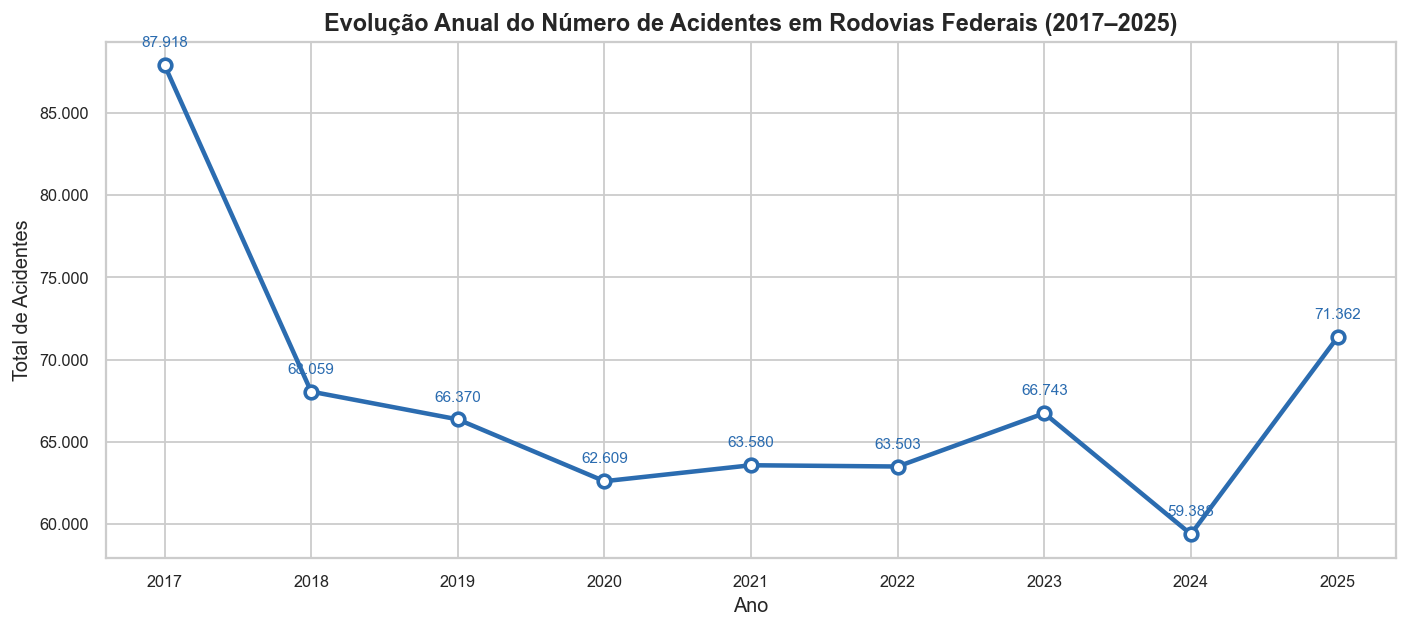

In [73]:
# Gráfico 1 — Evolução anual do número de acidentes (2017–2025)

acidentes_br['ano'] = acidentes_br['data_inversa'].dt.year

evolucao_anual = acidentes_br.groupby('ano').size().reset_index(name='total_acidentes')

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    evolucao_anual['ano'],
    evolucao_anual['total_acidentes'],
    marker='o', linewidth=2.5, markersize=7,
    color='#2b6cb0', markerfacecolor='white', markeredgewidth=2
)

for _, row in evolucao_anual.iterrows():
    ax.annotate(
        f"{int(row['total_acidentes']):,}".replace(',', '.'),
        (row['ano'], row['total_acidentes']),
        textcoords='offset points', xytext=(0, 10),
        ha='center', fontsize=8.5, color='#2b6cb0'
    )

ax.set_title('Evolução Anual do Número de Acidentes em Rodovias Federais (2017–2025)')
ax.set_xlabel('Ano')
ax.set_ylabel('Total de Acidentes')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
ax.set_xticks(evolucao_anual['ano'])

plt.tight_layout()
plt.savefig(os.path.join(pasta_graficos, '01_evolucao_anual.png'), bbox_inches='tight')
plt.show()

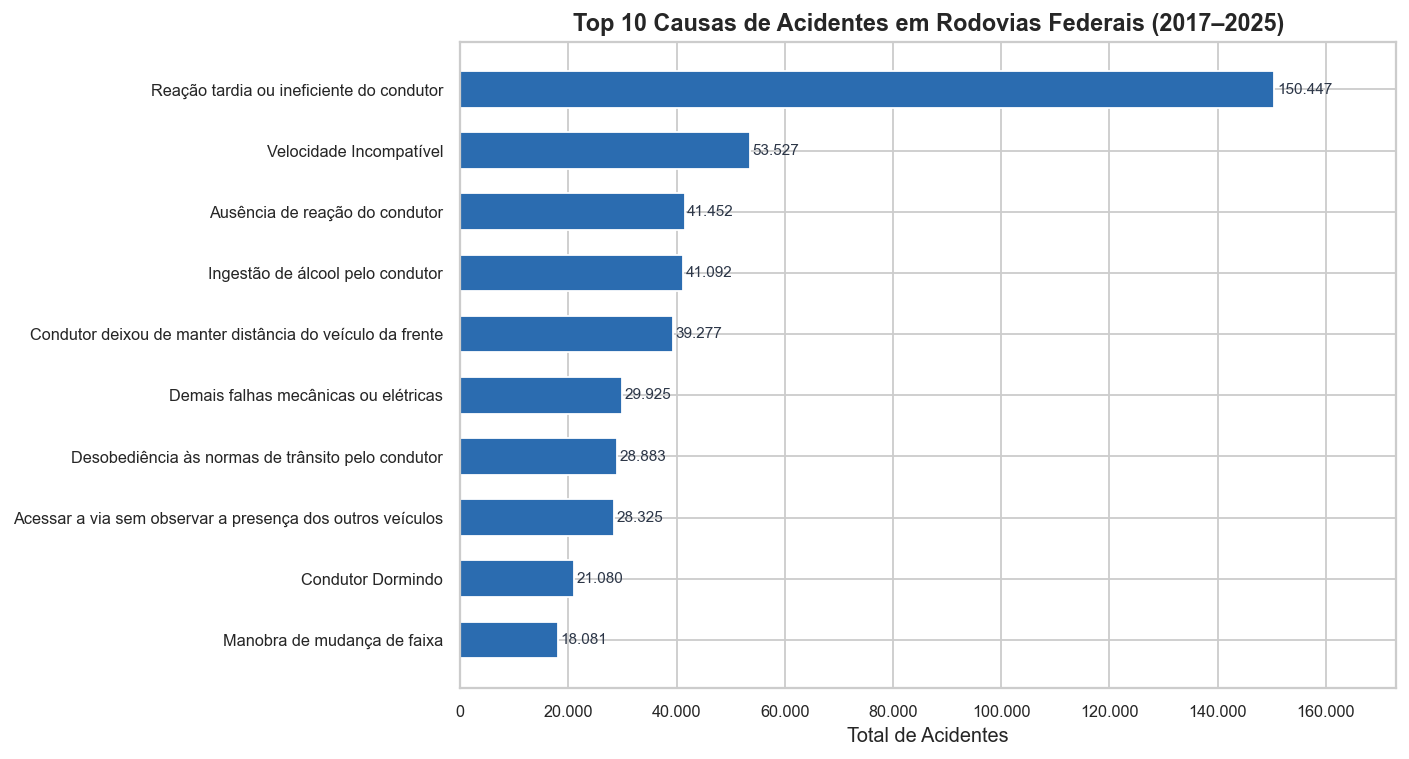

In [74]:
# Gráfico 2 — Top 10 causas de acidentes mais frequentes

top_causas = (
    acidentes_br['causa_acidente']
    .value_counts()
    .head(10)
    .reset_index()
)
top_causas.columns = ['causa_acidente', 'total']
top_causas = top_causas.sort_values('total')

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    top_causas['causa_acidente'],
    top_causas['total'],
    color='#2b6cb0', edgecolor='white', height=0.6
)

for bar in bars:
    ax.text(
        bar.get_width() + 500,
        bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width()):,}".replace(',', '.'),
        va='center', fontsize=8.5, color='#2d3748'
    )

ax.set_title('Top 10 Causas de Acidentes em Rodovias Federais (2017–2025)')
ax.set_xlabel('Total de Acidentes')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
ax.set_xlim(0, top_causas['total'].max() * 1.15)

plt.tight_layout()
plt.savefig(os.path.join(pasta_graficos, '02_top10_causas.png'), bbox_inches='tight')
plt.show()

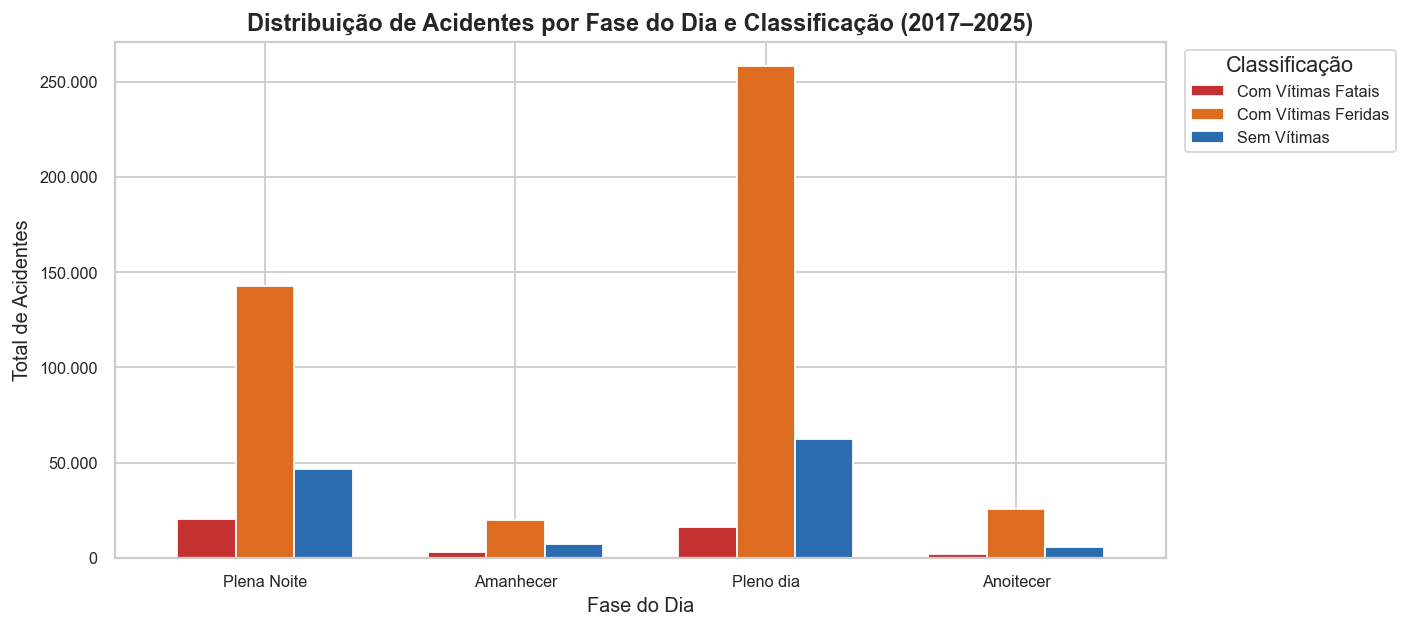

In [75]:
# Gráfico 3 — Distribuição de acidentes por fase do dia e classificação

ordem_fase = ['Plena Noite', 'Amanhecer', 'Pleno dia', 'Anoitecer']
ordem_class = ['Com Vítimas Fatais', 'Com Vítimas Feridas', 'Sem Vítimas']

fase_class = (
    acidentes_br
    .groupby(['fase_dia', 'classificacao_acidente'])
    .size()
    .reset_index(name='total')
)

fase_class = fase_class[
    fase_class['fase_dia'].isin(ordem_fase) &
    fase_class['classificacao_acidente'].isin(ordem_class)
]

pivot = fase_class.pivot(index='fase_dia', columns='classificacao_acidente', values='total').fillna(0)
pivot = pivot.reindex(index=ordem_fase, columns=ordem_class)

fig, ax = plt.subplots(figsize=(11, 5))

cores = ['#c53030', '#dd6b20', '#2b6cb0']
pivot.plot(kind='bar', ax=ax, color=cores, edgecolor='white', width=0.7)

ax.set_title('Distribuição de Acidentes por Fase do Dia e Classificação (2017–2025)')
ax.set_xlabel('Fase do Dia')
ax.set_ylabel('Total de Acidentes')
ax.set_xticklabels(ordem_fase, rotation=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
ax.legend(title='Classificação', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(pasta_graficos, '03_fase_dia_classificacao.png'), bbox_inches='tight')
plt.show()

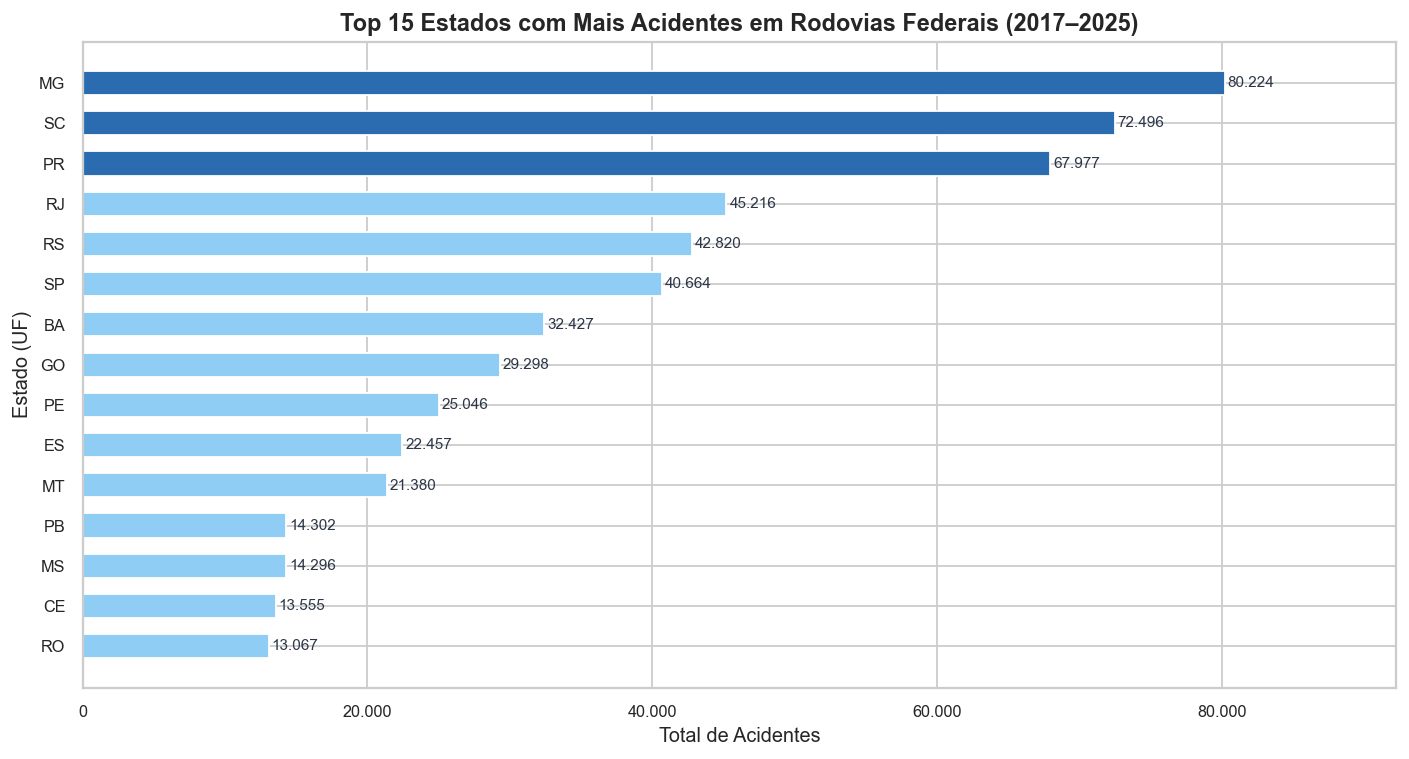

In [76]:
# Gráfico 4 — Top 15 estados com mais acidentes

top_uf = (
    acidentes_br['uf']
    .value_counts()
    .head(15)
    .reset_index()
)
top_uf.columns = ['uf', 'total']
top_uf = top_uf.sort_values('total')

fig, ax = plt.subplots(figsize=(11, 6))

cores_uf = ['#2b6cb0' if i >= len(top_uf) - 3 else '#90cdf4' for i in range(len(top_uf))]

bars = ax.barh(
    top_uf['uf'], top_uf['total'],
    color=cores_uf, edgecolor='white', height=0.6
)

for bar in bars:
    ax.text(
        bar.get_width() + 200,
        bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width()):,}".replace(',', '.'),
        va='center', fontsize=8.5, color='#2d3748'
    )

ax.set_title('Top 15 Estados com Mais Acidentes em Rodovias Federais (2017–2025)')
ax.set_xlabel('Total de Acidentes')
ax.set_ylabel('Estado (UF)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
ax.set_xlim(0, top_uf['total'].max() * 1.15)

plt.tight_layout()
plt.savefig(os.path.join(pasta_graficos, '04_top15_estados.png'), bbox_inches='tight')
plt.show()

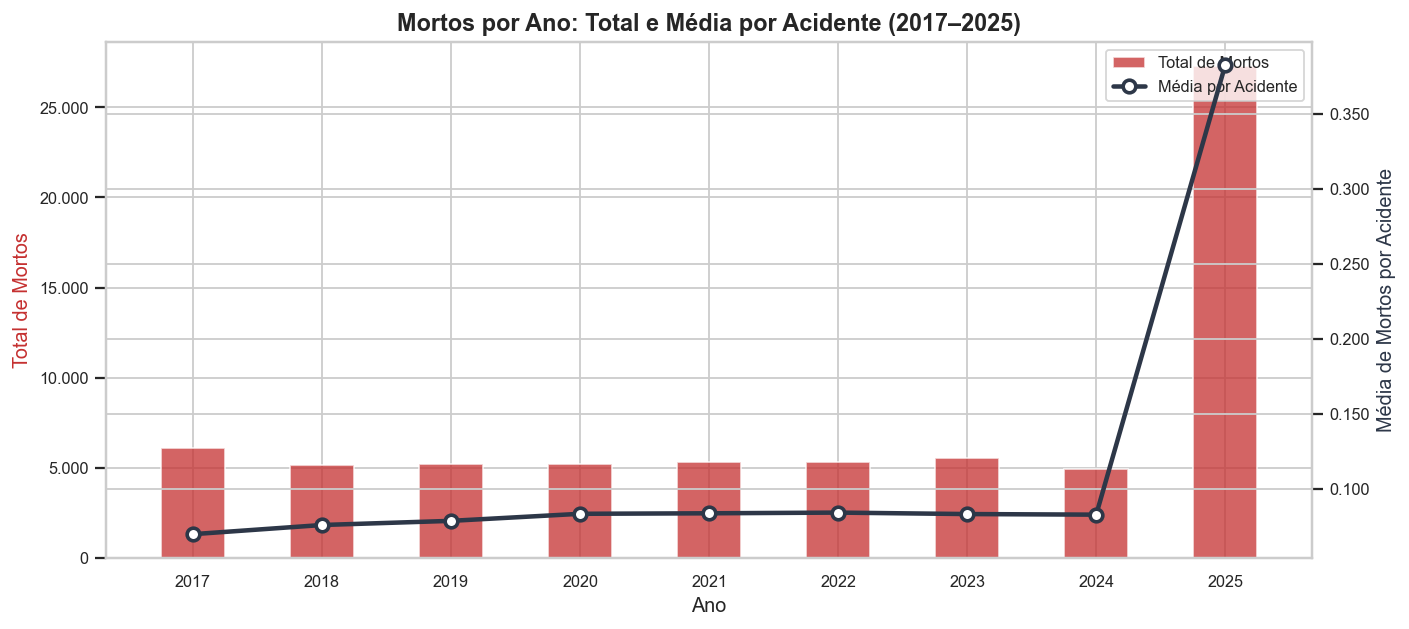

In [77]:
# Gráfico 5 — Mortos por ano: total e média por acidente

mortos_ano = acidentes_br.groupby('ano').agg(
    total_mortos=('mortos', 'sum'),
    total_acidentes=('id', 'count')
).reset_index()

mortos_ano['media_mortos_por_acidente'] = mortos_ano['total_mortos'] / mortos_ano['total_acidentes']

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.bar(
    mortos_ano['ano'], mortos_ano['total_mortos'],
    color='#c53030', alpha=0.75, width=0.5, label='Total de Mortos'
)
ax2.plot(
    mortos_ano['ano'], mortos_ano['media_mortos_por_acidente'],
    marker='o', linewidth=2.5, markersize=7,
    color='#2d3748', markerfacecolor='white', markeredgewidth=2,
    label='Média por Acidente'
)

ax1.set_title('Mortos por Ano: Total e Média por Acidente (2017–2025)')
ax1.set_xlabel('Ano')
ax1.set_ylabel('Total de Mortos', color='#c53030')
ax2.set_ylabel('Média de Mortos por Acidente', color='#2d3748')
ax1.set_xticks(mortos_ano['ano'])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.3f}'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(pasta_graficos, '05_mortos_por_ano.png'), bbox_inches='tight')
plt.show()

In [ ]:
import os

# Exportando o dataset final tratado para CSV
acidentes_br.to_csv(
    'Dados/acidentes_br_tratado.csv',
    index=False,
    sep=';',
    encoding='utf-8-sig'
)

print(f"Dataset exportado com sucesso!")
print(f"Arquivo: Dados/acidentes_br_tratado.csv")
print(f"Shape: {acidentes_br.shape}")
print(f"Colunas: {acidentes_br.columns.tolist()}")

Dataset exportado com sucesso!
Arquivo: Dados/acidentes_br_tratado.csv
Shape: (609532, 28)
Colunas: ['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop', 'fonte', 'ano']


## Próximas Etapas

A partir do dataset final exportado neste notebook:

- **`2-Feature_Engineering.ipynb`** — Criação da variável alvo `acidente_fatal`,
  extração de features temporais, encoding de variáveis categóricas e
  normalização para uso no modelo de ML
- **`3-Modelo_ML.ipynb`** — Treinamento, avaliação e interpretação do modelo
  de Machine Learning para predição de acidentes fatais
- **Power BI** — Importação do CSV exportado para criação dos dashboards interativos